# Chapter 21 — The History of Numbers

> **Prerequisites:** Part I complete — especially ch001 (Why Programmers Learn Math) and ch006 (Discrete vs Continuous Thinking)
> 
> **You will learn:**
> - Why number systems were extended historically, and the mathematical problem each extension solved
> - The tower: ℕ ⊂ ℤ ⊂ ℚ ⊂ ℝ ⊂ ℂ
> - How each extension corresponds to gaining closure under a new operation
> - How these extensions map to Python's numeric types
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The number systems you use every day were not handed down whole. They were built incrementally over millennia, each extension motivated by a specific deficiency in the prior system.

The pattern is always the same: *we try to perform an operation and discover there is no number to hold the result.* So we invent one.

| Operation | Problem | Extension Needed |
|---|---|---|
| `5 - 8` | No natural number holds this | Integers ℤ |
| `1 / 3` | No integer holds this | Rationals ℚ |
| `√2` | No rational holds this | Reals ℝ |
| `√(-1)` | No real holds this | Complex ℂ |

Each row in this table is a mathematical crisis that forced a conceptual expansion. The expansions are nested: every natural number is an integer, every integer is rational, and so on.

**Common misconception:** "Irrational numbers are just numbers we haven't expressed as fractions yet." Wrong. It was *proved* that √2 cannot be expressed as a ratio of integers — the proof is a few lines long and you will see it in ch025.

## 2. Intuition & Mental Models

**Geometric model:** Think of each number system as a ruler. Natural numbers are notches at whole positions. Integers add notches to the left of zero. Rationals add infinitely many notches between every pair of existing notches — yet somehow gaps remain. Reals fill those gaps. Complex numbers add a second dimension perpendicular to the real line.

**Computational model:** Think of each extension as gaining the ability to represent a new kind of result. A machine that only has integers throws an error on `1/3`. A machine with rationals handles it exactly, but throws an error on `sqrt(2)`. A machine with reals approximates `sqrt(2)` but refuses `sqrt(-1)`. Each type system you add to the machine corresponds to a number system extension.

**Closure:** Mathematicians say a set is *closed under an operation* if performing that operation on members of the set always produces another member. ℕ is closed under addition and multiplication, but *not* subtraction. ℤ is closed under subtraction but not division. This language — closure — will reappear in ch121 (Vector Spaces) and throughout linear algebra.

*(The concept of closure introduced here reappears in ch121 — What is a Vector?, where vector spaces are defined by exactly the same closure requirements.)*

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_23848\1861185556.py:44: UserWarning: Glyph 8469 (\N{DOUBLE-STRUCK CAPITAL N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23848\1861185556.py:44: UserWarning: Glyph 8484 (\N{DOUBLE-STRUCK CAPITAL Z}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23848\1861185556.py:44: UserWarning: Glyph 8474 (\N{DOUBLE-STRUCK CAPITAL Q}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23848\1861185556.py:44: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23848\1861185556.py:44: UserWarning: Glyph 8450 (\N{DOUBLE-STRUCK CAPITAL C}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8469 (\N{DOUBLE-STRUCK CAPITAL N}) mi

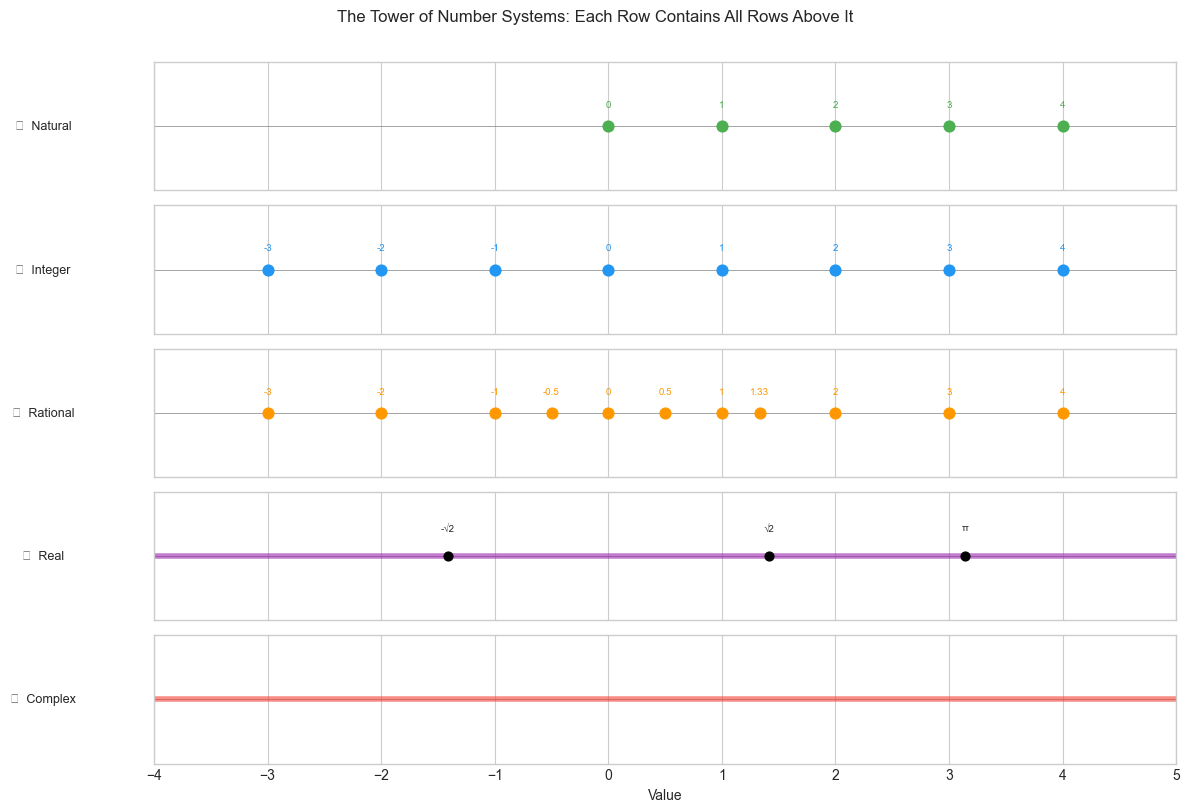

In [1]:
# --- Visualization: The number line tower ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)

XMIN, XMAX = -4, 5
x_line = np.linspace(XMIN, XMAX, 1000)

configs = [
    # (label, color, points to mark)
    ('ℕ  Natural', '#4CAF50', [0, 1, 2, 3, 4]),
    ('ℤ  Integer', '#2196F3', [-3, -2, -1, 0, 1, 2, 3, 4]),
    ('ℚ  Rational', '#FF9800', [-3, -2, -1, -0.5, 0, 0.5, 1, 4/3, 2, 3, 4]),
    ('ℝ  Real', '#9C27B0', None),   # continuous
    ('ℂ  Complex', '#F44336', None), # note: shown as real axis only
]

for ax, (label, color, pts) in zip(axes, configs):
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_yticks([])
    ax.set_ylabel(label, fontsize=9, rotation=0, labelpad=80, va='center')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(-0.5, 0.5)

    if pts is not None:
        ax.scatter(pts, [0]*len(pts), color=color, s=60, zorder=3)
        # Show special points
        for p in pts:
            ax.annotate(str(round(p, 2)), (p, 0.15), ha='center', fontsize=7, color=color)
    else:
        # Draw a dense line for continuous sets
        ax.plot(x_line, np.zeros_like(x_line), color=color, linewidth=4, alpha=0.6)
        if label.startswith('ℝ'):
            # Mark √2 and π
            for val, name in [(np.sqrt(2), '√2'), (np.pi, 'π'), (-np.sqrt(2), '-√2')]:
                ax.scatter([val], [0], color='black', s=40, zorder=4)
                ax.annotate(name, (val, 0.2), ha='center', fontsize=7)

axes[-1].set_xlabel('Value')
fig.suptitle('The Tower of Number Systems: Each Row Contains All Rows Above It', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

The containment relationship is written:

$$\mathbb{N} \subset \mathbb{Z} \subset \mathbb{Q} \subset \mathbb{R} \subset \mathbb{C}$$

Where:
- $\mathbb{N} = \{0, 1, 2, 3, \ldots\}$ — natural numbers (counting)
- $\mathbb{Z} = \{\ldots, -2, -1, 0, 1, 2, \ldots\}$ — integers (from German *Zahlen*)
- $\mathbb{Q} = \{p/q \mid p \in \mathbb{Z}, q \in \mathbb{Z}, q \neq 0\}$ — rationals (from *quotient*)
- $\mathbb{R}$ — reals (includes all limits of rational sequences)
- $\mathbb{C} = \{a + bi \mid a, b \in \mathbb{R}\}$ — complex, where $i^2 = -1$

**Closure table:** For a set $S$ and operation $\star$, $S$ is closed under $\star$ if $\forall x, y \in S: x \star y \in S$.

| Set | + | − | × | ÷ | √(neg) |
|-----|---|---|---|---|--------|
| ℕ | ✓ | ✗ | ✓ | ✗ | ✗ |
| ℤ | ✓ | ✓ | ✓ | ✗ | ✗ |
| ℚ | ✓ | ✓ | ✓ | ✓ | ✗ |
| ℝ | ✓ | ✓ | ✓ | ✓ | ✗ |
| ℂ | ✓ | ✓ | ✓ | ✓ | ✓ |

## 5. Python Implementation

In [2]:
# --- Implementation: Number system types and closure tests ---
import math
from fractions import Fraction

def test_closure(operation_name, operands, operation_fn, type_check_fn):
    """
    Test whether a set of values is closed under an operation.

    Args:
        operation_name: str, human label
        operands: list of values representing the set
        operation_fn: function(a, b) -> result
        type_check_fn: function(result) -> bool, True if result is still in set

    Returns:
        None (prints results)
    """
    print(f"\nClosure under {operation_name}:")
    closed = True
    for a in operands:
        for b in operands:
            try:
                result = operation_fn(a, b)
                if not type_check_fn(result):
                    print(f"  FAILS: {a} op {b} = {result} (exits the set)")
                    closed = False
            except (ZeroDivisionError, ValueError):
                print(f"  FAILS: {a} op {b} = undefined")
                closed = False
    if closed:
        print(f"  CLOSED")


# Natural numbers: test subtraction
naturals = [0, 1, 2, 3, 4, 5]
test_closure(
    "subtraction (ℕ)",
    naturals,
    lambda a, b: a - b,
    lambda r: r >= 0 and isinstance(r, int)
)

# Integers: test division
integers = [-2, -1, 1, 2, 3]
test_closure(
    "division (ℤ)",
    integers,
    lambda a, b: a / b,
    lambda r: isinstance(r, int) or r == int(r)
)

# Rationals: test division (using Fraction for exact arithmetic)
rationals = [Fraction(1, 2), Fraction(3, 4), Fraction(2, 1)]
test_closure(
    "division (ℚ, using Fraction)",
    rationals,
    lambda a, b: a / b,
    lambda r: isinstance(r, Fraction)
)

print("\n--- Python's number types ---")
print(f"int(5):            {type(5)}       — approximates ℤ")
print(f"float(5.0):        {type(5.0)}     — approximates ℝ (imperfectly)")
print(f"complex(1+2j):     {type(1+2j)}    — exactly ℂ")
print(f"Fraction(1,3):     {type(Fraction(1,3))} — exactly ℚ")
print(f"Fraction(1,3):     {Fraction(1,3)} — exact representation")


Closure under subtraction (ℕ):
  FAILS: 0 op 1 = -1 (exits the set)
  FAILS: 0 op 2 = -2 (exits the set)
  FAILS: 0 op 3 = -3 (exits the set)
  FAILS: 0 op 4 = -4 (exits the set)
  FAILS: 0 op 5 = -5 (exits the set)
  FAILS: 1 op 2 = -1 (exits the set)
  FAILS: 1 op 3 = -2 (exits the set)
  FAILS: 1 op 4 = -3 (exits the set)
  FAILS: 1 op 5 = -4 (exits the set)
  FAILS: 2 op 3 = -1 (exits the set)
  FAILS: 2 op 4 = -2 (exits the set)
  FAILS: 2 op 5 = -3 (exits the set)
  FAILS: 3 op 4 = -1 (exits the set)
  FAILS: 3 op 5 = -2 (exits the set)
  FAILS: 4 op 5 = -1 (exits the set)

Closure under division (ℤ):
  FAILS: -2 op 3 = -0.6666666666666666 (exits the set)
  FAILS: -1 op -2 = 0.5 (exits the set)
  FAILS: -1 op 2 = -0.5 (exits the set)
  FAILS: -1 op 3 = -0.3333333333333333 (exits the set)
  FAILS: 1 op -2 = -0.5 (exits the set)
  FAILS: 1 op 2 = 0.5 (exits the set)
  FAILS: 1 op 3 = 0.3333333333333333 (exits the set)
  FAILS: 2 op 3 = 0.6666666666666666 (exits the set)
  FAILS: 3

## 6. Experiments

In [3]:
# --- Experiment 1: Rational arithmetic is exact; float is not ---
# Hypothesis: Fraction objects accumulate no rounding error; floats do
# Try changing: the number of terms N

from fractions import Fraction

N = 100  # <-- modify this

# Sum 1/1 + 1/2 + 1/3 + ... + 1/N
float_sum = sum(1/k for k in range(1, N+1))
exact_sum = sum(Fraction(1, k) for k in range(1, N+1))

print(f"Float sum:    {float_sum}")
print(f"Exact sum:    {float(exact_sum):.15f}")
print(f"Error:        {abs(float_sum - float(exact_sum)):.2e}")
print(f"Exact frac:   {exact_sum}")

Float sum:    5.187377517639621
Exact sum:    5.187377517639621
Error:        0.00e+00
Exact frac:   14466636279520351160221518043104131447711/2788815009188499086581352357412492142272


Distinct rationals in [0,1] with denominator ≤ 10: 33


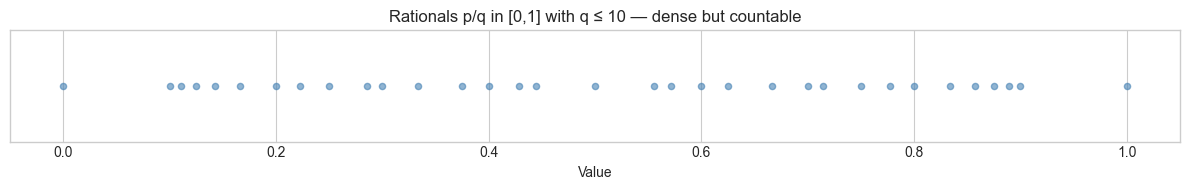

In [4]:
# --- Experiment 2: How many rationals fit between 0 and 1? ---
# Hypothesis: infinitely many, but we can enumerate pairs (p, q)
# Try changing: MAX_DENOM

MAX_DENOM = 10  # <-- modify this

rationals_in_01 = set()
for q in range(1, MAX_DENOM + 1):
    for p in range(0, q + 1):
        rationals_in_01.add(Fraction(p, q))

sorted_rats = sorted(rationals_in_01)
print(f"Distinct rationals in [0,1] with denominator ≤ {MAX_DENOM}: {len(sorted_rats)}")

# Plot them on a line
fig, ax = plt.subplots(figsize=(12, 2))
x_vals = [float(r) for r in sorted_rats]
ax.scatter(x_vals, [0]*len(x_vals), s=20, alpha=0.6, color='steelblue')
ax.set_xlim(-0.05, 1.05)
ax.set_yticks([])
ax.set_xlabel('Value')
ax.set_title(f'Rationals p/q in [0,1] with q ≤ {MAX_DENOM} — dense but countable')
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** List three operations for which ℕ is closed, and two for which it is not. *(Expected: written answer)*

**Easy 2.** In Python, compute `Fraction(1, 7) * 7`. What does the result tell you about exact rational arithmetic? *(Expected: single line of code + explanation)*

**Medium 1.** Write a function `is_rational_approx(x, max_denom=1000)` that returns the closest rational `p/q` to a float `x` where `q ≤ max_denom`. Test it on `math.pi` and `math.sqrt(2)`. *(Hint: use `Fraction.limit_denominator`)*

**Medium 2.** Write code to demonstrate that between any two distinct rationals `a < b`, there exists another rational `c` with `a < c < b`. Generate 5 such triples programmatically. *(Hint: think about `(a + b) / 2`)*

**Hard.** The Stern-Brocot tree enumerates all positive rationals exactly once with no repeats. Implement a generator `stern_brocot(n)` that yields the first `n` fractions in Stern-Brocot order. Verify no fraction appears twice in the first 50 terms.

## 8. Mini Project

In [5]:
# --- Mini Project: Number System Explorer ---
# Problem: Build a tool that takes a numeric expression and identifies
#          which number system its result lives in.
# Dataset: Generated test cases
# Task: Classify results and visualize the distribution

import math
from fractions import Fraction

def classify_number(x):
    """
    Classify a number into the smallest number system that contains it.

    Args:
        x: a Python number (int, float, complex, Fraction)

    Returns:
        str: one of 'Natural', 'Integer', 'Rational', 'Real', 'Complex'
    """
    # TODO: implement classification logic
    # Hint: check isinstance, then check for negativity, then check
    # if float can be expressed as Fraction with small denominator
    pass

# Test cases — your classifier should label each correctly
test_cases = [
    (42, "Natural"),
    (-7, "Integer"),
    (Fraction(1, 3), "Rational"),
    (0.5, "Rational"),
    (math.sqrt(2), "Real"),
    (math.pi, "Real"),
    (1 + 2j, "Complex"),
    (complex(0, 1), "Complex"),
]

print("Value                 Expected     Got")
print("-" * 50)
for val, expected in test_cases:
    got = classify_number(val)
    status = "✓" if got == expected else "✗"
    print(f"{str(val):<22} {expected:<12} {got} {status}")

Value                 Expected     Got
--------------------------------------------------
42                     Natural      None ✗
-7                     Integer      None ✗
1/3                    Rational     None ✗
0.5                    Rational     None ✗
1.4142135623730951     Real         None ✗
3.141592653589793      Real         None ✗
(1+2j)                 Complex      None ✗
1j                     Complex      None ✗


## 9. Chapter Summary & Connections

- Number systems form a tower: ℕ ⊂ ℤ ⊂ ℚ ⊂ ℝ ⊂ ℂ. Each level was invented to solve a closure failure in the level below.
- The key concept is **closure**: a set is closed under an operation if the result always stays in the set.
- Python provides exact arithmetic via `Fraction` (for ℚ) and `complex` (for ℂ); `float` only approximates ℝ.
- Irrational numbers are provably not expressible as ratios — this will be shown rigorously in ch025.

**Forward connections:**
- This chapter's tower reappears in ch027 (Complex Numbers), where we build intuition for ℂ geometrically.
- The concept of closure under operations becomes the *definition* of a vector space in ch121 — What is a Vector?
- Rational approximation of reals connects directly to ch037 (Precision and Floating Point Errors).

**Backward connection:**
- This chapter operationalizes the abstraction and modeling mindset from ch003 — the number tower is itself a model, built to solve a sequence of real computational failures.

**Going deeper:** Georg Cantor's diagonal argument (1891) proves that ℝ is strictly *larger* than ℚ in a precise sense — there are more real numbers than rational numbers, even though both sets are infinite. Look up "Cantor's diagonal argument" when you want a genuinely mind-altering proof.